In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
from collections import defaultdict


In [9]:
output_folder=("../PhysiCell/results/stochastic_cell_cycle/cell_volumes.csv")
pc_df = pd.read_csv(output_folder,float_precision='round_trip').sort_values(by=['dt']).reset_index(drop=True)
pc_df

,id,x,y,z,total_volume,current_phase,dt
0,0.0,0.000000,0.000000,0.000000,523.600000,4.0,0.0
1,0.0,0.000000,0.000000,0.000000,523.600000,4.0,30.0
2,0.0,0.000000,0.000000,0.000000,523.600000,4.0,60.0
3,0.0,0.000000,0.000000,0.000000,523.600000,10.0,90.0
4,0.0,0.000000,0.000000,0.000000,548.770598,10.0,120.0
...,...,...,...,...,...,...,...
359,8.0,-0.065806,6.107596,6.814443,514.907288,4.0,2880.0
360,12.0,-1.511294,-3.775737,13.496676,391.869285,10.0,2880.0
361,0.0,9.720622,-4.832263,0.151310,901.593933,10.0,2880.0
362,9.0,-6.461507,0.928968,-9.185060,723.570967,10.0,2880.0


In [10]:
output_folder=("../Biodynamo/unit_test_cellcycle_stoch/new_results/output/")
cell_indices = [0, 2, 3, 4]

# Dictionary to accumulate volumes at each timestep
volume_by_time = defaultdict(float)

# Read and accumulate volume per timestep
for idx in cell_indices:
    fname = os.path.join(output_folder, f'cell-{idx}.csv')
    df = pd.read_csv(fname, names=['timestep', 'volume', 'Phase', 'Age'], header=0)

    for _, row in df.iterrows():
        timestep = row['timestep']
        volume = row['volume']
        volume_by_time[timestep] += volume

# Convert to DataFrame
bd_df = pd.DataFrame(sorted(volume_by_time.items()), columns=['timestep', 'total_volume'])

# (Optional) Normalize by initial total volume (first timestep)
initial_volume = bd_df.iloc[0]['total_volume']
bd_df['volume_percent'] = (bd_df['total_volume'] / initial_volume) * 100
bd_df

,timestep,total_volume,volume_percent
0,0.02,523.599,100.000000
1,0.03,523.599,100.000000
2,0.04,523.599,100.000000
3,0.05,523.599,100.000000
4,0.06,523.599,100.000000
...,...,...,...
4794,47.96,2926.802,558.977767
4795,47.97,2929.877,559.565049
4796,47.98,2932.949,560.151757
4797,47.99,2936.016,560.737511


In [11]:
output_folder=("../Chaste/unit_test_cellcycle_stoch/results/cellcycle_stochastic.dat")
ch_df = pd.DataFrame(columns=["dt","id","x","y","z","g1_duration","s_duration","g2_duration","m_duration","current_phase","target_area","volume"])
with open(output_folder, "r") as f:
    for line in f.read().splitlines():
        data = line.split()
        data = [float(x) if x.replace('.', '', 1).isdigit() else x for x in data]
        dt = data[0]
        for i in range(0,len(data)//11):
            row = {'dt': dt, 'id': data[1+11*i], 'x': data[2+11*i], 'y': data[3+11*i], 'z': data[4+11*i], 'g1_duration': data[5+11*i], 's_duration': data[6+11*i], 'g2_duration': data[7+11*i], 'm_duration': data[8+11*i], 'current_phase': data[9+11*i], 'target_area': data[10+11*i], 'volume': data[11+11*i]}
            row = pd.Series(row)
            df2 = pd.DataFrame(row).transpose()

            ch_df =pd.concat([ch_df,df2],ignore_index=True)
ch_df

,dt,id,x,y,z,g1_duration,s_duration,g2_duration,m_duration,current_phase,target_area,volume
0,0.0,0.0,0.0,0.0,0.1,7.25521,6.32044,2.80048,2.1526,G1,0.523599,0.523599
1,0.1,0.0,0.0,0.0,3.0,7.25521,6.32044,2.80048,2.1526,G1,0.523599,0.523599
2,0.2,0.0,0.0,0.0,3.0,7.25521,6.32044,2.80048,2.1526,G1,0.523599,0.523599
3,0.3,0.0,0.0,0.0,3.0,7.25521,6.32044,2.80048,2.1526,G1,0.523599,0.523599
4,0.4,0.0,0.0,0.0,3.0,7.25521,6.32044,2.80048,2.1526,G1,0.523599,0.523599
...,...,...,...,...,...,...,...,...,...,...,...,...
977,47.9,3.0,1.16217,-0.244869,2.75488,8.11108,5.51073,2.80928,2.18411,S,0.684275,0.682703
978,48.0,0.0,-1.05816,-0.324506,2.78837,6.25944,5.19225,2.93086,1.7571,S,0.826768,0.825525
979,48.0,1.0,0.071579,-0.193753,2.99288,6.5616,7.18621,2.98239,1.83951,S,0.797384,0.795568
980,48.0,2.0,-0.532432,0.750143,2.85549,7.94535,5.58975,3.4465,1.86309,S,0.717101,0.715756


In [12]:
output_folder=("../Tisim/unit_test_cellcycle_stoch/cell cycle stochastic.csv")
data = pd.read_csv(output_folder, header=0)
time_steps = data['time (hour)']
volume_columns = data.columns[1:]  # Assuming all other columns are cell volumes

average_volumes = data[volume_columns].mean(axis=1, skipna=True)
initial_total_volume = average_volumes.iloc[0]

percentage_total_volumes = (average_volumes / initial_total_volume)*100
# print(percentage_total_volumes)
# Create a new DataFrame with time steps and percentage of total volumes
ts_df = pd.DataFrame({
    'timestep': time_steps,
    'volumes': percentage_total_volumes
})
ts_df



,timestep,volumes
0,1,100.00000
1,2,100.00000
2,3,100.00000
3,4,100.00000
4,5,100.00000
5,6,100.00000
6,7,119.55800
7,8,138.40700
8,9,154.09300
9,10,167.03500


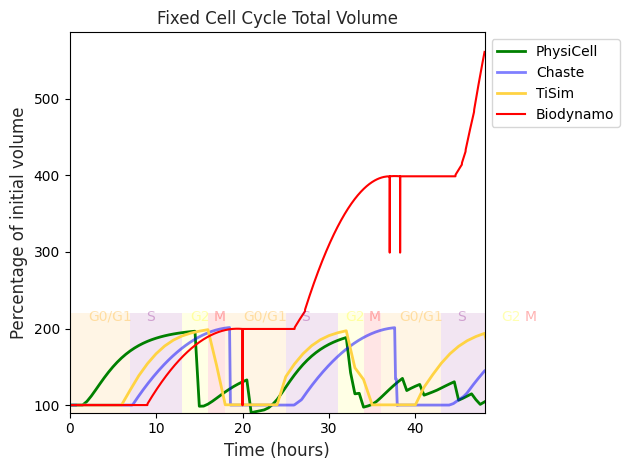

In [13]:
fig, ax = plt.subplots()

# Normalize time to hours
pc_df['dt'] = pc_df['dt'] / 60
pc_init_vol = pc_df.iloc[0]["total_volume"]

# Compute average volume per time step (normalized)
pc_avg_vol = pc_df.groupby('dt')['total_volume'].mean()
pc_dts = pc_avg_vol.index
pc_vols = (pc_avg_vol / pc_init_vol * 100).tolist()

# Plot PhysiCell
ax.plot(pc_dts, pc_vols, label="PhysiCell", color='green', linewidth=2)

# Chaste
ch_init_vol = ch_df.loc[0, "volume"]
ch_avg_vol = ch_df.groupby('dt')['volume'].mean()
dts = ch_avg_vol.index
vols = (ch_avg_vol / ch_init_vol * 100).tolist()
ax.plot(dts, vols, label="Chaste", color='blue', linewidth=2, alpha=0.5)

# TiSim
ax.plot(ts_df['timestep'], ts_df['volumes'], label="TiSim", color='#ffd343', linewidth=2)

# BioDynaMo
ax.plot(bd_df['timestep'], bd_df["volume_percent"], label="Biodynamo", color="red")

# Add phase background rectangles (G0/G1, S, G2, M)
for i in range(3):  # repeat 3 cell cycles
    base = 18 * i
    phases = [
        (base, 7, 'orange', 'G0/G1'),
        (base + 7, 6, 'purple', 'S'),
        (base + 13, 3, 'yellow', 'G2'),
        (base + 16, 2, 'red', 'M'),
    ]
    for x, w, color, label in phases:
        ax.add_patch(patches.Rectangle((x, 50), w, 170, facecolor=color, alpha=0.1, edgecolor=None))
        if label in ['G2', 'M']:
            ax.text(x + w * 0.3, 210, label, color=color, alpha=0.3)
        else:
            ax.text(x + w * 0.3, 210, label, color=color, alpha=0.3)

# Final plot formatting
ax.set_xlim(0, 48)
ax.set_ylim(90)
ax.set_xlabel("Time (hours)", fontsize=12, color='#262626')
ax.set_ylabel("Percentage of initial volume", fontsize=12, color='#262626')
ax.set_title('Fixed Cell Cycle Total Volume', color='#262626')
ax.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')
plt.tight_layout()
plt.savefig("stochastic.png", dpi=200)
plt.show()